# Multiple Linear Regression

Extending simple linear regression to more than one input feature. The model still fits a straight line — just in higher-dimensional space, so with two features it's a plane, and with more it's a hyperplane.

**What changes vs. Simple Linear Regression?**
- `y = m1*x1 + m2*x2 + ... + mk*xk + b` — one slope (coefficient) per feature
- Same `.fit()` / `.predict()` API — sklearn doesn't care how many features you pass in
- R² alone can be misleading here — adding *any* feature can only increase R², even a useless one, so **adjusted R²** matters more as feature count grows

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Adding a Second Feature to Real Data

Start with the same `placement.csv` used in simple linear regression, but add a second feature and compare R² / adjusted R² to see whether it actually helps.

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.48,2.37
1,6.84,2.79
2,4.76,1.72
3,8.54,4.32
4,5.11,2.22


In [3]:
# Add a random (uninformative) feature to test whether R2 can be misleading
np.random.seed(2)
df_multi = df.copy()
df_multi['random_feature'] = np.random.randint(-100, 100, df_multi.shape[0])
df_multi.head()

,cgpa,package,random_feature
0,6.48,2.37,68
1,6.84,2.79,-85
2,4.76,1.72,-28
3,8.54,4.32,-78
4,5.11,2.22,-57


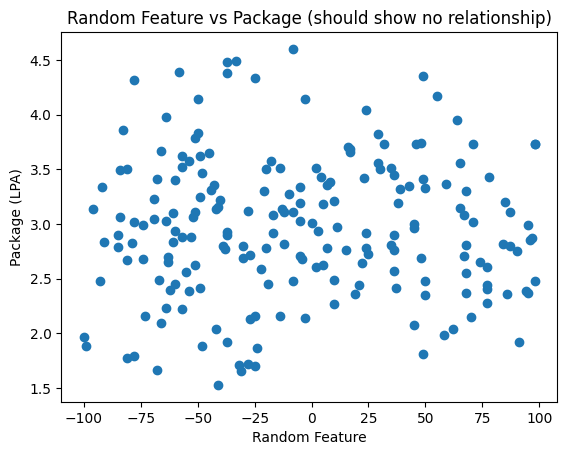

In [4]:
plt.scatter(df_multi['random_feature'], df_multi['package'])
plt.xlabel('Random Feature')
plt.ylabel('Package (LPA)')
plt.title('Random Feature vs Package (should show no relationship)')
plt.show()

## 2. Fit with Two Features

In [5]:
X = df_multi[['cgpa', 'random_feature']]
y = df_multi['package']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 score: {r2:.4f}")

R2 score: 0.7218


In [6]:
# Compare against adjusted R2 to see whether the random feature actually helped
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"Adjusted R2: {adjusted_r2:.4f}")

Adjusted R2: 0.7068


Adding the random feature barely moves R², and adjusted R² accounts for the extra feature's cost — this is exactly the behavior adjusted R² is meant to catch: a useless feature shouldn't be rewarded just for existing.

## 3. A Genuinely Informative Second Feature

Now compare against a feature that plausibly *does* relate to package — e.g. an IQ-style score — to see the difference in R² / adjusted R² when the added feature is actually useful.

In [7]:
np.random.seed(3)
df_multi2 = df.copy()
df_multi2['iq'] = np.round(100 + (df_multi2['package'] - df_multi2['package'].mean()) * 15
                            + np.random.normal(0, 8, df_multi2.shape[0]))
df_multi2.sample(5)

,cgpa,package,iq
10,7.45,2.71,86.0
73,6.97,2.80,112.0
14,7.44,3.05,102.0
41,7.67,2.78,102.0
17,8.08,3.70,99.0


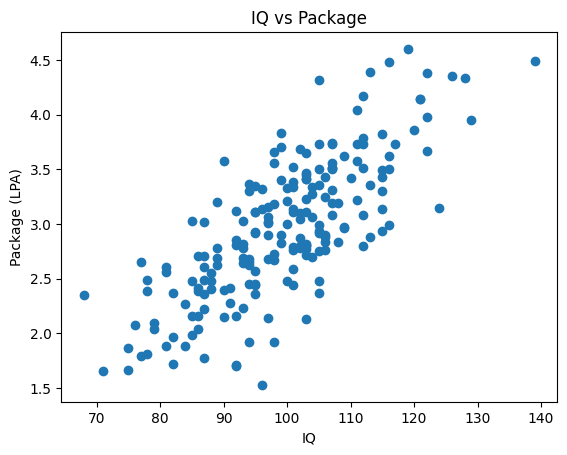

In [8]:
plt.scatter(df_multi2['iq'], df_multi2['package'])
plt.xlabel('IQ')
plt.ylabel('Package (LPA)')
plt.title('IQ vs Package')
plt.show()

In [9]:
X = df_multi2[['cgpa', 'iq']]
y = df_multi2['package']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 score: {r2:.4f}")

R2 score: 0.7345


In [10]:
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"Adjusted R2: {adjusted_r2:.4f}")

Adjusted R2: 0.7202


## 4. Geometric Intuition with Synthetic 3D Data

With exactly 2 features, the regression fit is a **plane**, not a line. Synthetic data via `make_regression` plus a 3D scatter plot makes this visible directly.

In [11]:
X, y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50, random_state=13)

synth_df = pd.DataFrame({'feature1': X[:,0], 'feature2': X[:,1], 'target': y})
synth_df.head()

,feature1,feature2,target
0,1.892742,0.490872,216.617730
1,0.514329,0.217452,76.023958
2,-0.389656,0.291641,-63.806961
3,0.817306,0.154205,172.989994
4,0.501137,1.749242,56.024963


In [12]:
fig = px.scatter_3d(synth_df, x='feature1', y='feature2', z='target')
fig.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)

MAE: 46.59102684546021
Coefficients: [78.52632743 30.44600105]
Intercept: -0.2320506193570373


In [14]:
# Overlay the fitted plane on the 3D scatter
x_surf = np.linspace(synth_df['feature1'].min(), synth_df['feature1'].max(), 10)
y_surf = np.linspace(synth_df['feature2'].min(), synth_df['feature2'].max(), 10)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = lr.intercept_ + lr.coef_[0]*x_surf + lr.coef_[1]*y_surf

fig = px.scatter_3d(synth_df, x='feature1', y='feature2', z='target')
fig.add_traces(px.scatter_3d(x=x_surf.flatten(), y=y_surf.flatten(), z=z_surf.flatten()).data)
fig.show()

---
## Multiple Linear Regression Cheat Sheet

Quick reference for the patterns shown above.

### Fitting with Multiple Features
| Code | Description |
|---|---|
| `df[['feat1','feat2']]` | Select multiple columns as 2D input for `X` |
| `lr.fit(X_train, y_train)` | Same API regardless of feature count |
| `lr.coef_` | Array of coefficients, one per feature, in column order |

### Adjusted R² (why it matters more here)
| Code | Description |
|---|---|
| `1 - ((1-r2)*(n-1)/(n-k-1))` | Penalizes R² for each added feature — use when comparing models with different feature counts |
| — | Plain R² can only increase (or stay flat) as features are added, even useless ones |

### Geometric Intuition
| Concept | Description |
|---|---|
| 1 feature | Fitted model is a line |
| 2 features | Fitted model is a plane |
| 3+ features | Fitted model is a hyperplane (no longer visualizable directly) |

### Gotchas
- More features → always check adjusted R², not just R²
- Random/irrelevant features can still slightly increase plain R² — don't trust it alone
- `make_regression(noise=...)` is useful for quickly generating synthetic data with a known relationship for testing